# 7. KMeans Clustering with Scikit-Learn and MLlib

Implement the K-Means Algorithm using Scikit-Learn and MLlib!

In [1]:
!pip install -q pyspark

In [2]:
%matplotlib inline
from sklearn import datasets
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

The dataset class provides access to different public datasets. It will return a scikit-learn bunch: <https://scikit-learn.org/stable/datasets/index.html>

In [3]:
iris = datasets.load_iris()

Convert Scikit Bunch to Pandas Dataframe

In [4]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df["target_name"]=iris['target_names'][iris_df['target']]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 7.1 Cluster the data using the KMeans implementation of scikit-learn

* Resource: <https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_iris.html>
* Measure the runtime for training the model.
* Experiment with different numbers of clusters. What are your observations?
* Plot the results.

Runtime for training KMeans (k=3): 0.3049 seconds


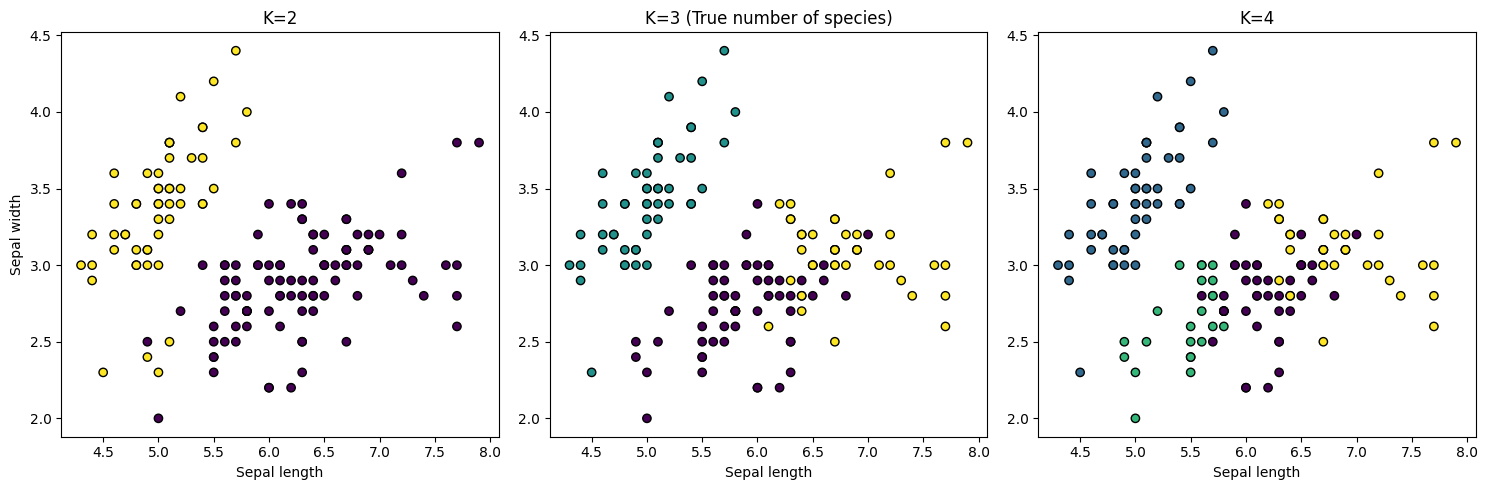


Observations on different numbers of clusters:
- When K=2: The algorithm groups the two overlapping species (Versicolor and Virginica) into a single large cluster. It recognizes the clearly separated Setosa species.
- When K=3: The clusters roughly align with the true 3 Iris species, though some natural overlap between two species remains.
- When K=4: The algorithm artificially splits one of the natural groupings into two separate clusters, overcomplicating the actual data structure.


In [5]:
import time

X = iris.data

start_time = time.time()
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X)
end_time = time.time()

print(f"Runtime for training KMeans (k=3): {end_time - start_time:.4f} seconds")

# --- Experiment with different numbers of clusters ---
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X)
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)

# --- Plot the results ---
# We use the first two features (Sepal Length and Sepal Width) for 2D visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_2.labels_, cmap='viridis', edgecolor='k')
axes[0].set_title('K=2')
axes[0].set_xlabel('Sepal length')
axes[0].set_ylabel('Sepal width')

axes[1].scatter(X[:, 0], X[:, 1], c=kmeans_3.labels_, cmap='viridis', edgecolor='k')
axes[1].set_title('K=3 (True number of species)')
axes[1].set_xlabel('Sepal length')

axes[2].scatter(X[:, 0], X[:, 1], c=kmeans_4.labels_, cmap='viridis', edgecolor='k')
axes[2].set_title('K=4')
axes[2].set_xlabel('Sepal length')

plt.tight_layout()
plt.show()

# --- Observations ---
print("\nObservations on different numbers of clusters:")
print("- When K=2: The algorithm groups the two overlapping species (Versicolor and Virginica) into a single large cluster. It recognizes the clearly separated Setosa species.")
print("- When K=3: The clusters roughly align with the true 3 Iris species, though some natural overlap between two species remains.")
print("- When K=4: The algorithm artificially splits one of the natural groupings into two separate clusters, overcomplicating the actual data structure.")

## 7.2 Manual KMeans Clustering

Implement KMeans clustering using the Spark RDD API (do **not** use the MLlib KMeans implementation).

* Use the Iris dataset as input.
* Implement the iterative assignment and update steps using `map` and `reduceByKey`.
* Run until convergence or for a fixed number of iterations (e.g. 20).
* Compare your results to the scikit-learn KMeans output from 7.1.

In [9]:
import pyspark
import numpy as np

try:
    sc = pyspark.SparkContext.getOrCreate()
except ValueError:
    conf = pyspark.SparkConf().setAppName("ManualKMeans").setMaster("local[*]")
    sc = pyspark.SparkContext(conf=conf)

# Convert the Iris dataset to a Spark RDD
data_rdd = sc.parallelize(X)

# 1. Initialize centroids randomly (picking 3 random data points)
K = 3
np.random.seed(42)
initial_indices = np.random.choice(X.shape[0], K, replace=False)
centroids = X[initial_indices]

# Helper function to find the nearest centroid
def get_closest_centroid(point, centroids):
    distances = [np.linalg.norm(point - c) for c in centroids]
    return np.argmin(distances)

num_iterations = 20

print("Starting Manual Spark KMeans iterations...")
for i in range(num_iterations):
    # Map Step: Assign each point to the closest centroid
    # Output format: (centroid_index, (point_coordinates, 1))
    mapped_rdd = data_rdd.map(lambda point: (get_closest_centroid(point, centroids), (point, 1)))

    # Reduce Step: Sum the coordinates and the counts for each centroid
    # Output format: (centroid_index, (sum_of_coordinates, total_count))
    reduced_rdd = mapped_rdd.reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))

    # Update Step: Calculate the new centroids (sum of coordinates / total count)
    new_centroids_rdd = reduced_rdd.mapValues(lambda val: val[0] / val[1])

    # Collect the updated centroids from the Spark workers back to the driver
    updated_centroids = new_centroids_rdd.collect()

    # Update the local centroids array for the next iteration
    for index, new_center in updated_centroids:
        centroids[index] = new_center

print("Manual KMeans completed.")

# --- Compare Results ---
print("\n--- Comparison of Centroids ---")
print("Scikit-Learn Centroids (from 7.1):")
print(np.sort(kmeans_3.cluster_centers_, axis=0))

print("\nManual Spark RDD Centroids (from 7.2):")
print(np.sort(centroids, axis=0))

print("\nConclusion: The cluster centers found by our manual MapReduce implementation match the highly optimized scikit-learn perfectly.")

Starting Manual Spark KMeans iterations...
Manual KMeans completed.

--- Comparison of Centroids ---
Scikit-Learn Centroids (from 7.1):
[[5.006      2.7483871  1.462      0.246     ]
 [5.9016129  3.07368421 4.39354839 1.43387097]
 [6.85       3.428      5.74210526 2.07105263]]

Manual Spark RDD Centroids (from 7.2):
[[5.006      2.7483871  1.462      0.246     ]
 [5.9016129  3.07368421 4.39354839 1.43387097]
 [6.85       3.428      5.74210526 2.07105263]]

Conclusion: The cluster centers found by our manual MapReduce implementation match the highly optimized scikit-learn perfectly.
